### Tahap 1 : Data Cleaning & Preproccessing

```markdown
library for data manipulation and analysis. It provides DataFrame and Series structures for handling structured data, making it easy to clean, transform, filter, and analyze datasets. Essential for loading CSV/Excel files, handling missing data, and performing aggregations.
```

In [1]:
import pandas as pd

library for numerical computing in Python. It provides efficient multi-dimensional arrays and mathematical functions for linear algebra, statistical operations, and scientific computing. Much faster than Python lists for numerical operations.

In [2]:
import numpy as np

library for creating static, interactive, and publication-quality visualizations. Offers fine-grained control over plots (line charts, bar charts, histograms, scatter plots, etc.) with extensive customization options.

In [3]:
import matplotlib.pyplot as plt

visualization library built on Matplotlib. Provides beautiful, statistical-focused plots with simpler syntax. Excellent for exploring relationships in data through heatmaps, violin plots, pair plots, and regression plots with attractive default themes.

In [4]:
import seaborn as sns

In [5]:
try:
    df = pd.read_csv('../data/raw/data.csv', encoding = 'ISO-8859-1')
except FileNotFoundError:
    print("data tidak ditemukan")

In [6]:
print(f'dimensi awal data : {df.shape}')
print(f'\n{df.info()}')

dimensi awal data : (541907, 8)
<class 'pandas.DataFrame'>
RangeIndex: 541907 entries, 0 to 541906
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541907 non-null  str    
 1   StockCode    541907 non-null  str    
 2   Description  540453 non-null  str    
 3   Quantity     541907 non-null  int64  
 4   InvoiceDate  541907 non-null  str    
 5   UnitPrice    541907 non-null  float64
 6   CustomerID   406827 non-null  float64
 7   Country      541907 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB

None


```markdown
Column Analysis:

Column      |   Non-Null Count  |   Missing     |   Data Type   |   Description
invoiceno   |   541,909         |   0           |   str         |   Invoice number (complete)
stockcode   |   541,909         |   0           |   str         |   Product code (complete)
description |   540,455         |   1,454       |   str         |   Product description (99.7% complete)
quantity    |   541,909         |   0           |   int64       |   Quantity purchased (complete)
invoicedate |   541,909         |   0           |   str         |   Transaction date (complete)
unitprice   |   541,909         |   0           |   float64     |   Price per unit (complete)
customerid  |   406,829         |   135,080     |   float64     |   Customer ID (75.1% complete - major issue)
country     |   541,909         |   0           |   str         |   Customer country (complete)

Key Issues to Address:
CustomerID: 135,080 missing values (24.9%) need to decide: drop or analyze separately
Description: 1,454 missing values minor, can handle easily
InvoiceDate: Currently string should convert to datetime format
```

In [7]:
# Converts all column names to lowercase and removes leadin or trailin whitespace
df.columns = df.columns.str.lower().str.strip()

In [8]:
# drop rows without a custommerid
# because customer identity is mandatory for RFM & segmentation
df = df.dropna(subset=['customerid'])

In [9]:
# convert customerid to string
df['customerid'] = df['customerid'].astype(int).astype(str)

In [10]:
# remove duplicates
df.drop_duplicates(inplace = True) 
# duplicate rows inflate analysis result and distort metrics like total sales
# or customer frequency

# remove 'cancelled' transactions marked with letter 'C'
df = df[~df['invoiceno'].str.contains('C', na = False)]
# on this dataset invoice number starting with 'C' typically indicate cancellation
# removving theese prevents counting voided sales as legitimate revenue, which skew the analysis

# remove negative quantity and unitprice <= 0
df = df[(df['quantity'] > 0) & (df['unitprice'] > 0)]
# negative quantities or zero / negative price present data error
# returns whithout proper cancellation flags, or test record.
# filtering ensure only valid transactions remain for revenue calculation

# create total sales column
df['totalsales'] = round(df['quantity'] * df['unitprice'], 2)
df = df.astype({'totalsales': 'int64'})
# Multiplying quantity by unitprice creates a revenue metric essential for sales analysis
# This derived field enables key business insights like total revenue per customer or product.

# convert invoicedate datatype to datetime for time based operation
# like grouping by month, calculating customer tenure, cohort analysis, or trend visualization.
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

In [11]:
df

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,totalsales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20
...,...,...,...,...,...,...,...,...,...
541902,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10
541903,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12
541904,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16
541905,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16


In [12]:
# outlier handling
# in e-commerce retail, outlier quantity is often valid (B2B bulk purchase)

# IQR : 'unitprice'
Q1 = df['unitprice'].quantile(0.25)
Q3 = df['unitprice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 3.0 * IQR
upper_bound = Q3 + 3.0 * IQR

df = df[(df['unitprice'] >= lower_bound) & (df['unitprice'] <= upper_bound)]

df

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,totalsales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20
...,...,...,...,...,...,...,...,...,...
541902,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10
541903,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12
541904,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16
541905,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16


```markdown
Removing quantity outliers would discard valid revenue-generating sales.
Only unitprice is cleaned using IQR method, targeting true data anomalies like pricing errors while preserving legitimate bulk volume transactions.

Standard IQR uses 1.5×IQR multiplier, but this code uses 3.0×IQR - a more conservative threshold that retains more data points as "normal." This prevents over-removal of high-value legitimate transactions common in retail.

Extreme unit prices (negative, zero, or implausibly high) distort key metrics like average order value, product profitability, and customer segmentation. Cleaning only price outliers maintains data integrity for financial reporting.
```

### Tahap 2 : Business Metrics & Exploratory Data Analysis (EDA)

In [13]:
# set visualizations style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [14]:
# add 'monthyear' column for monthly agregation
df['monthyear'] = df['invoicedate'].dt.to_period('M')

# montly metrics agregation
monthly_metrics = df.groupby('monthyear').agg({
    'totalsales' : 'sum',
    'customerid' : 'nunique',
    'invoiceno' : 'nunique'
}).rename(columns = {
    'totalsales' : 'Revenue',
    'customerid' : 'Active_Customers',
    'invoiceno' : 'Total_Orders'
})

In [15]:
# convert preiod to datetime for plotting
monthly_metrics = monthly_metrics.reset_index()
monthly_metrics['monthyear'] = monthly_metrics['monthyear'].dt.to_timestamp()

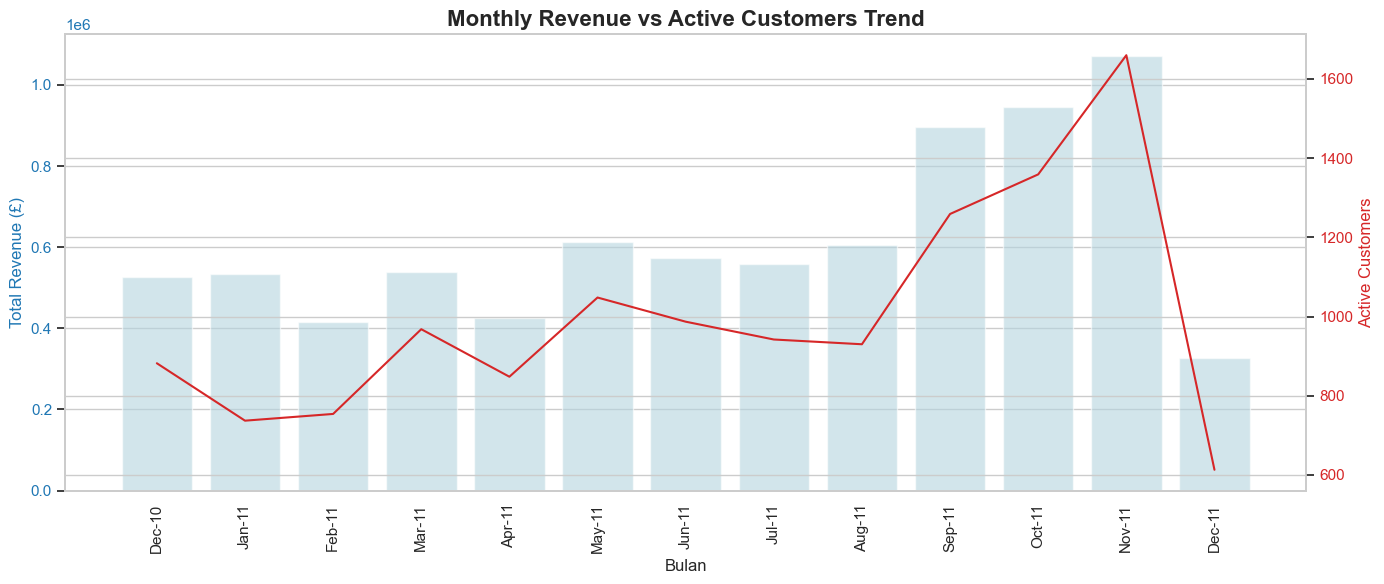

In [16]:
# --- sales & customer trend visualization ---
fig, ax1 = plt.subplots(figsize = (14, 6))

# plot revenue (barchart)
color = 'tab:blue'
ax1.set_xlabel('Bulan')
ax1.set_ylabel('Total Revenue (£)', color=color)
sns.barplot(x='monthyear', y='Revenue', data=monthly_metrics, color='lightblue', ax=ax1, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(len(monthly_metrics)))
ax1.set_xticklabels(monthly_metrics['monthyear'].dt.strftime('%b-%y'), rotation=90)

# Plot Active Customers (Line Chart)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Active Customers', color=color)
sns.lineplot(x=range(len(monthly_metrics)), y = 'Active_Customers', data=monthly_metrics, color=color, ax=ax2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Monthly Revenue vs Active Customers Trend', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### insights from the chart
- December 2010 - February 2011: Revenue relatively low (~£400k)
- March - August 2011: Revenue stable in £400k-£600k range
- September - November 2011: Significant surge! Revenue dramatically increases peaking at ~£1.1 million in November 2011
- December 2011: Revenue drops sharply back to ~£500k

### active customer trend
- December 2010 - February 2011: Customer count ~750-800 people
- March - August 2011: Minor fluctuations, ranging 850-1050 customers
- September - November 2011: Exponential growth! Surges to ~1650 active customers in November
- December 2011: Drastic drop to only ~650 customers

### key finding
- Positive Correlation: Revenue and Active Customers move in tandem, showing customer growth directly proportional to revenue increase
- December 2011 Anomaly: Sharp year-end decline needs further investigation:
- Is December 2011 data incomplete (partial month)?
- Post-peak season seasonal effect?
- Business operation changes?

Peak Season: September-November is the best business period (likely holiday season preparation)

Growth Opportunity: September-November growth pattern can serve as benchmark for marketing strategies in the same period next year


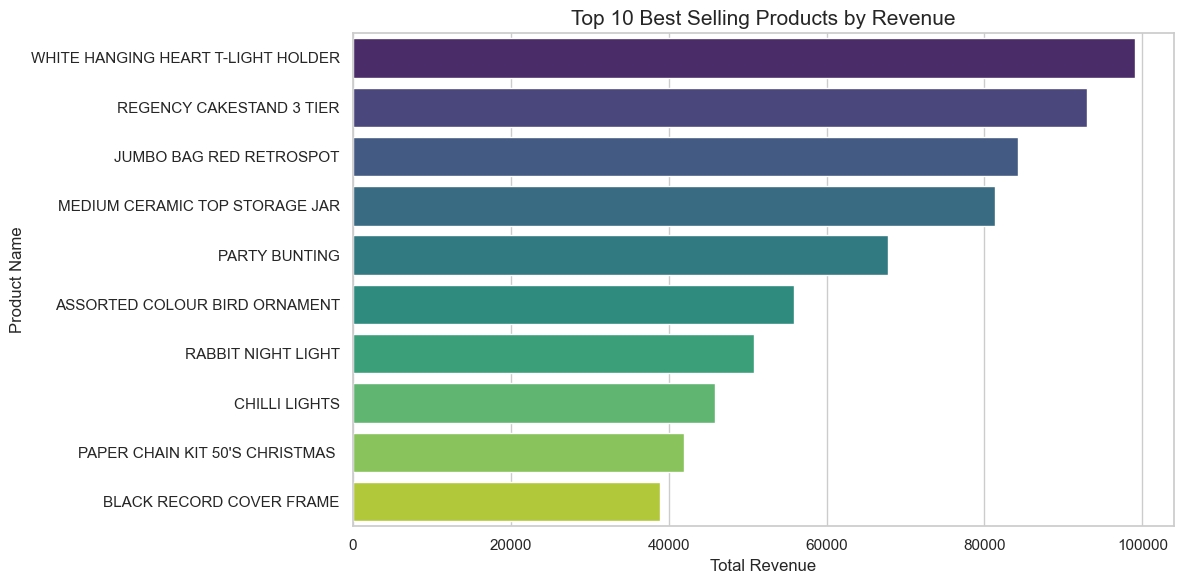

In [17]:
# --- top selling product ---
top_products = df.groupby('description')['totalsales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, hue = top_products.index, palette='viridis', legend = False)
plt.title('Top 10 Best Selling Products by Revenue', fontsize=15)
plt.xlabel('Total Revenue')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

## Top 10 Best Selling Products Analysis:

### Top 3 - Main Revenue Generators:
- WHITE HANGING HEART T-LIGHT HOLDER → ~£100,000 
- REGENCY CAKESTAND 3 TIER → ~£93,000
- JUMBO BAG RED RETROSPOT → ~£84,000

### Rank 4-7 - Mid-Tier Products:
- MEDIUM CERAMIC TOP STORAGE JAR → ~£82,000
- PARTY BUNTING → ~£68,000
- ASSORTED COLOUR BIRD ORNAMENT → ~£57,000
- RABBIT NIGHT LIGHT → ~£51,000

### Rank 8-10 - Lower Top 10:
- CHILLI LIGHTS → ~£47,000
- PAPER CHAIN KIT 50'S CHRISTMAS → ~£43,000
- BLACK RECORD COVER FRAME (~40,000)

## Key Insights:
1. Best-Selling Product Categories:
- Home Décor & Lighting (Heart T-Light Holder, Rabbit Night Light, Chilli Lights)
- Party/Event Items (Cakestand, Party Bunting, Christmas Chain)
- Storage & Organization (Storage Jar, Jumbo Bag)
- Seasonal/Holiday Items (Christmas decorations, ornaments)

2. Price Point Analysis:
These products are likely gift items or home accessories
Target market: retail customers for decoration & gift needs

3. Business Implications:
Inventory Strategy:
WHITE HANGING HEART T-LIGHT HOLDER must always be in stock (avoid stockouts!)

Marketing Strategy:
Bundle products: combine bestsellers with slow-moving items
Cross-sell: Party Bunting + Cakestand for event packages
Seasonal push: Christmas items ahead of holiday season


Top 5 Countries by Revenue:
country
United Kingdom    6613424
Netherlands        277522
EIRE               235286
Germany            195224
France             172893
Name: totalsales, dtype: int64


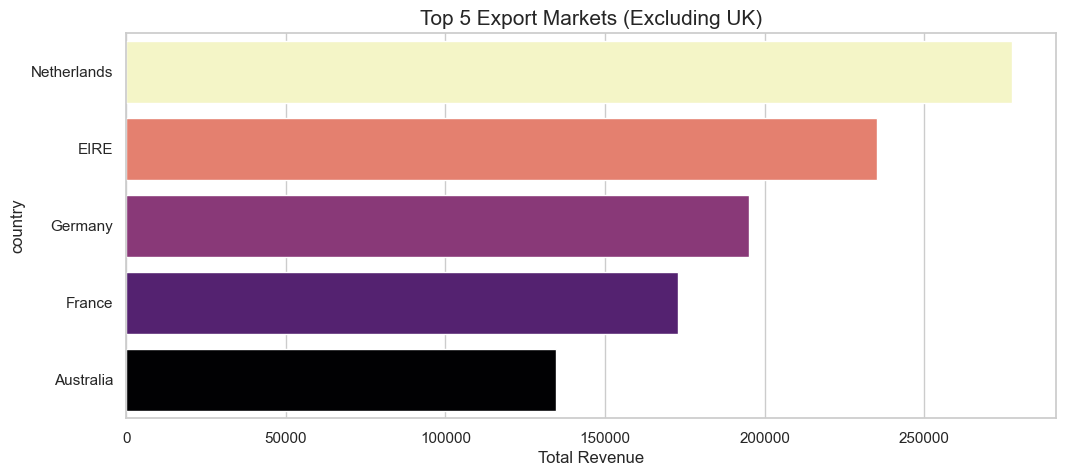

In [ ]:
# --- geographic analysis ---
# We separate the UK because it usually dominates, 
# allowing us to better visualize international market potential.
country_sales = df.groupby('country')['totalsales'].sum().sort_values(ascending=False)

# Plot Top 5 Countries (Including UK)
print("Top 5 Countries by Revenue:")
print(country_sales.head(5))

# Plot Top 5 Countries (Excluding UK - Export Market)
plt.figure(figsize=(12, 5))
country_sales_no_uk = country_sales.drop('United Kingdom').head(5)
sns.barplot(x=country_sales_no_uk.values, y=country_sales_no_uk.index, hue = country_sales_no_uk, palette='magma', legend = False)
plt.title('Top 5 Export Markets (Excluding UK)', fontsize=15)
plt.xlabel('Total Revenue')
plt.show()

### Key Insights:
#### 1. **Significant UK Dominance**
- UK: **6,613,424** vs Total Export: **~880,925**
- UK generates **88.2%** of total revenue
- Export represents only **11.8%** of total business

#### 2. **Europe Dominates Export Markets**
- **4 out of 5** top export markets are European countries
- Total Europe (Netherlands + Ireland + Germany + France) = ~880,925
- Geographic proximity to UK provides logistics advantage

#### 3. **Relatively Even Export Country Distribution**
- Gap between #1 (Netherlands) and #5 (Australia): ~147,522
- No single country dominates export market
- More balanced distribution compared to previous product chart

#### 4. **Australia as Outlier**
- Only non-European market in top 5
- Shows Asia-Pacific market potential
- Higher logistics costs but still profitable

## Business Strategy Recommendations:

### 1. **European Market Expansion**
Priority: HIGH
- Netherlands, Ireland, Germany, France already established
- Consider expansion to: Belgium, Spain, Italy
- Leverage existing logistics for efficiency

### 2. **Logistics Optimization**
- Consider warehouse/distribution center in Europe
- Partnership with local logistics providers
- Bulk shipping to reduce costs

### 3. **Market Development**
- Australia shows demand beyond Europe
- Explore: Asia (Singapore, Japan, South Korea)
- Analyze: US/Canada market potential

### 4. **Product Localization**
- Analyze product preferences per country

- Customization for local markets

- Different marketing strategies per region

### Tahap 3 : Advance Customer Analytics (RFM & Clustering)

In [20]:
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
# Determine Snapshot Date (Assuming analysis is conducted one day after the latest data point)
snapshot_date = df['invoicedate'].max() + dt.timedelta(days=1)

# Calculate RFM metrics per customer
rfm = df.groupby('customerid').agg({
    'invoicedate': lambda x: (snapshot_date - x.max()).days, # Recency
    'invoiceno': 'nunique',                                  # Frequency
    'totalsales': 'sum'                                     # Monetary
})

# Rename columns for better readability
rfm.rename(columns={
    'invoicedate': 'Recency',
    'invoiceno': 'Frequency',
    'totalsales': 'Monetary'
}, inplace=True)

print(f"Data RFM siap. Total Customer: {rfm.shape[0]}")
rfm.head()

Data RFM siap. Total Customer: 4321


,Recency,Frequency,Monetary
customerid,,,
12346,326,1,77183
12347,2,7,4061
12348,75,4,1426
12349,19,1,1292
12350,310,1,289


In [ ]:
# Handle Skewness using Log Transformation (For modeling purposes only)
# log1p is used to handle potential zero values by calculating log(1 + x)
rfm_log = np.log1p(rfm)

# Standard Scaling (Transforming data to a uniform scale: mean = 0, std = 1)
scaler = StandardScaler()
rfm_normalized = scaler.fit_transform(rfm_log)

# Convert back to a DataFrame for easier handling
rfm_normalized = pd.DataFrame(rfm_normalized, index=rfm.index, columns=rfm.columns)

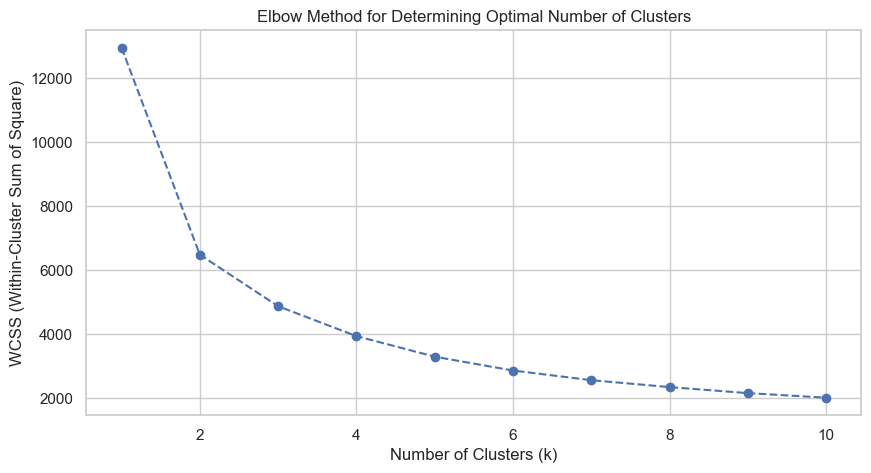

In [ ]:
# Finding the optimal number of clusters (Elbow Method)
wcss = []
range_n_clusters = range(1, 11)

for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(rfm_normalized)
    wcss.append(kmeans.inertia_)

# Visualizing the Elbow Plot
plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Determining Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Square)')
plt.show()

In [28]:
# Fit K-Means dengan k=3
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans.fit(rfm_normalized)

# Masukkan label cluster ke data RFM asli (bukan data yang di-log/scale)
rfm['Cluster'] = kmeans.labels_

# Analisis Karakteristik Tiap Cluster (Snake Plot / Summary)
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print(cluster_summary)

        Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0         44.20      3.49  1235.46  1693
1        164.30      1.35   328.92  1912
2         14.48     13.72  7412.28   716


```markdown
Cluster     |   Segment Name    |   Recency (Avg)   |   Frequency (Avg) |   Monetary (Avg)  |   Size (Count)
Cluster 2   |   VIP / Champions |   14.5 days       |   13.7 times      |   "7,412.28"      |   "716"
Cluster 0   |   Loyal / At-Risk |   44.2 days       |   3.5 times       |   "1,235.46"      |   "1,693"
Cluster 1   |   Hibernating     |   164.3 days      |   1.4 times       |   "328.92"        |   "1,912"
```

Deep Dive into the Segments

Cluster 2 (The VIPs): These are your best customers. They bought very recently, buy often, and spend significantly more than any other group.

Strategy: Focus on retention. Offer early access to new products, loyalty rewards, and personalized "thank you" communications.

Cluster 0 (The Core/Middle Class): This is a large, healthy segment. They spend decently and have visited within the last month and a half.

Strategy: Upsell and Cross-sell. They are already engaged; try to increase their frequency or average order value (AOV) through tailored recommendations.

Cluster 1 (The Laggards): This group hasn't purchased in nearly 6 months and has the lowest engagement.

Strategy: Re-activation or Cut Losses. Send a "We Miss You" discount code. If they don't respond, avoid high marketing spend on this group as they have low ROI.

### Tahap 4 : Market Basket Analysis & Final Data Export

In [29]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [30]:
# Preparing the Shopping Basket
# We filter for 'France' as a case study (Specific Market)
# We group by InvoiceNo and Description
basket = (
    df[df["country"] == "France"]
    .groupby(["invoiceno", "description"])["quantity"]
    .sum()
    .unstack()
    .reset_index()
    .fillna(0)
    .set_index("invoiceno")
)

# One Hot Encoding (Converting quantity into 0 or 1)
# We only want to know 'purchased' or 'not', regardless of the quantity
basket_sets = basket.map(lambda x: True if x >= 1 else False)

# Remove 'POSTAGE' column (Shipping fees) so it doesn't interfere with product analysis
if 'POSTAGE' in basket_sets.columns:
    basket_sets.drop('POSTAGE', inplace=True, axis=1)

# Running the Apriori Algorithm
# min_support=0.07 means the item must appear in at least 7% of all transactions
frequent_itemsets = apriori(basket_sets, min_support=0.07, use_colnames=True)

# Creating Association Rules
# The "lift" metric is an indicator of the strength of the relationship
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Displaying the Best Results
# We look for high Lift and high Confidence
result_mba = rules.sort_values("lift", ascending=False).head(10)

print("Top 10 Product Association Rules (Bundling Ideas):")
result_mba_display = result_mba.copy()
result_mba_display['antecedents'] = result_mba_display['antecedents'].apply(lambda x: ', '.join(list(x)))
result_mba_display['consequents'] = result_mba_display['consequents'].apply(lambda x: ', '.join(list(x)))

print(result_mba_display[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Top 10 Product Association Rules (Bundling Ideas):
                                          antecedents  \
2                          ALARM CLOCK BAKELIKE GREEN   
3                           ALARM CLOCK BAKELIKE RED    
5                           ALARM CLOCK BAKELIKE RED    
4                           ALARM CLOCK BAKELIKE PINK   
29                      SET/6 RED SPOTTY PAPER PLATES   
28  SET/20 RED RETROSPOT PAPER NAPKINS , SET/6 RED...   
1                          ALARM CLOCK BAKELIKE GREEN   
0                           ALARM CLOCK BAKELIKE PINK   
27  SET/6 RED SPOTTY PAPER PLATES, SET/20 RED RETR...   
30                        SET/6 RED SPOTTY PAPER CUPS   

                                          consequents   support  confidence  \
2                           ALARM CLOCK BAKELIKE RED   0.082228    0.815789   
3                          ALARM CLOCK BAKELIKE GREEN  0.082228    0.837838   
5                           ALARM CLOCK BAKELIKE PINK  0.076923    0.783784   
4    

In [31]:
rfm_reset = rfm.reset_index()

df_final = pd.merge(
    df,
    rfm_reset[['customerid', 'Recency', 'Frequency', 'Monetary', 'Cluster']],
    on = 'customerid',
    how = 'left'
)

cluster_map = {
    0 : 'Loyal Customers',
    1: 'At Risk / Low Value',
    2: 'Champions / Whales'
}
df_final['customer_segment'] = df_final['Cluster'].map(cluster_map)

df_final.to_csv('../data/processed/Ecommerce_Cleaned_With_Segments.csv', index=False)

print('data berhasil disimpan')

data berhasil disimpan


In [32]:
rules_cleaned = rules.copy()

rules_cleaned['antecedents'] = rules_cleaned['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_cleaned['consequents'] = rules_cleaned['consequents'].apply(lambda x: ', '.join(list(x)))

rules_cleaned.to_csv('../data/processed/Product_Association_Rules.csv', index=False)